<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/CIFAR_10_or_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build a CNN to classify handwritten digits from the MNIST dataset. Load and normalize the data, define an architecture with Conv2D and MaxPooling2D layers, train the model using the Adam optimizer, and evaluate its performance. Finally, visualize the training history and display sample predictions.

## Load and Preprocess MNIST Dataset

### Subtask:
Download the MNIST dataset, normalize pixel values, and reshape the data for CNN compatibility.


In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape to (batch_size, height, width, channels) for CNN compatibility
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Verify the shapes
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)
Training samples: 60000
Testing samples: 10000


## Train the Model

### Subtask:
Train the compiled CNN model on the training data and monitor its performance on a validation split.

**Reasoning**:
I will define the CNN architecture by importing the necessary Keras components and building a Sequential model with the specified convolutional, pooling, and dense layers.



In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Initialize the Sequential model
model = Sequential([
    # Add a Conv2D layer with 32 filters, 3x3 kernel, and 'relu' activation
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Add a MaxPooling2D layer with 2x2 pool size
    MaxPooling2D(pool_size=(2, 2)),
    # Add another Conv2D layer with 64 filters
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    # Add another MaxPooling2D layer
    MaxPooling2D(pool_size=(2, 2)),
    # Flatten the 2D feature maps to a 1D vector
    Flatten(),
    # Add a Dense layer with 128 units and 'relu' activation
    Dense(128, activation='relu'),
    # Final output layer with 10 units and 'softmax' activation
    Dense(10, activation='softmax')
])

# Display the model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Explain CNN Warning

### Subtask:
Provide a text explanation of the Keras UserWarning regarding model input specification.


## Compile the Model

### Subtask:
Configure the model for training by specifying the optimizer, loss function, and evaluation metrics.

In [5]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

print("Training complete.")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.8760 - loss: 0.3959 - val_accuracy: 0.9843 - val_loss: 0.0517
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.9833 - loss: 0.0558 - val_accuracy: 0.9887 - val_loss: 0.0435
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9895 - loss: 0.0337 - val_accuracy: 0.9875 - val_loss: 0.0406
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accuracy: 0.9900 - val_loss: 0.0374
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.9945 - loss: 0.0181 - val_accuracy: 0.9885 - val_loss: 0.0445
Training complete.


## Visualize Training History and Predictions

### Subtask:
Plot the training and validation metrics and display sample predictions with labels.

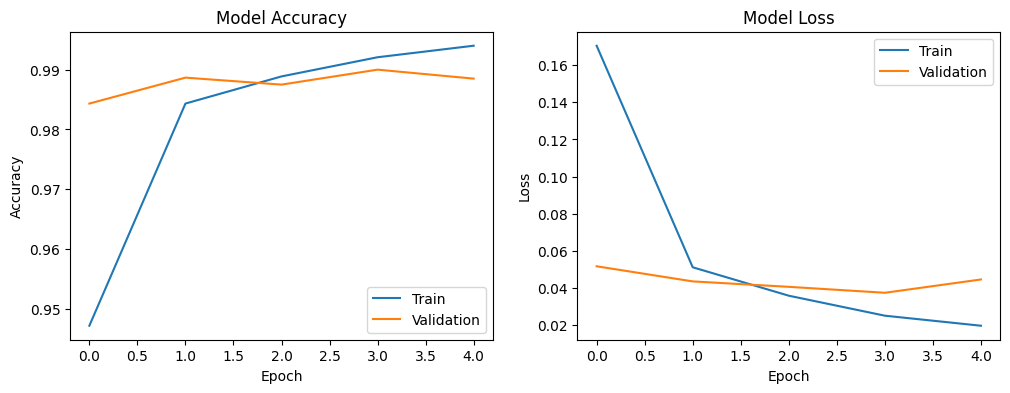

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


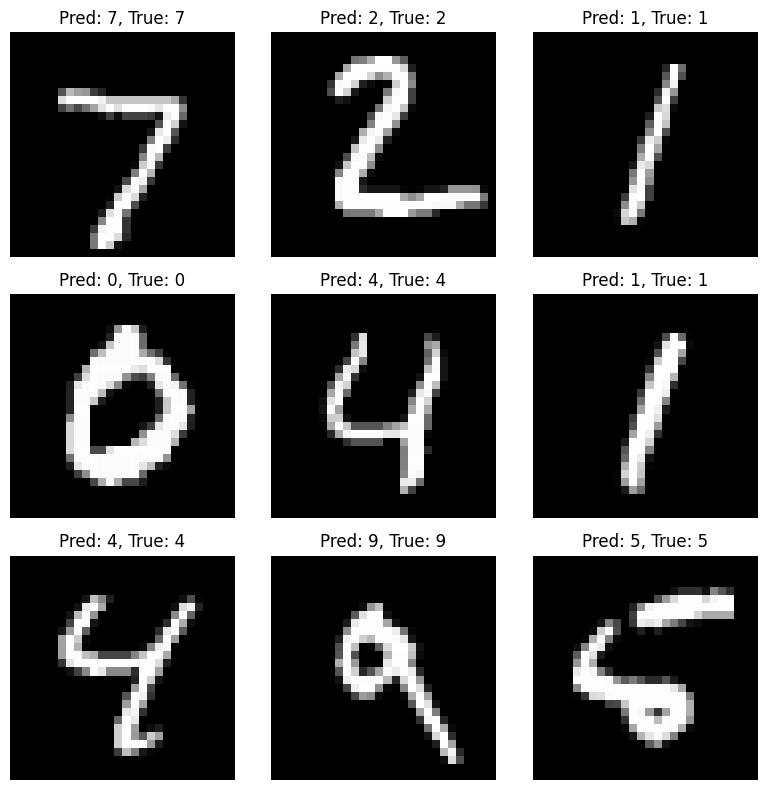

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Display sample predictions
predictions = model.predict(x_test[:9])
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Pred: {pred_label}, True: {true_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Evaluate the Model

### Subtask:
Assess the model's performance on the test dataset to verify generalization.

In [6]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

313/313 - 4s - 11ms/step - accuracy: 0.9890 - loss: 0.0360

Test accuracy: 0.9890
Test loss: 0.0360


## Update Model with Input Layer

### Subtask:
Redefine the CNN model using an explicit Input layer to resolve the Keras UserWarning.


**Reasoning**:
I will redefine the CNN model by incorporating an explicit Input layer to resolve the Keras UserWarning and maintain the established architecture.



In [3]:
from tensorflow.keras.layers import Input

# Redefine the model using an explicit Input layer to resolve UserWarnings
model = Sequential([
    # Define the input shape explicitly using the Input layer
    Input(shape=(28, 28, 1)),
    # First convolutional block
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    # Second convolutional block
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    # Transition to dense layers
    Flatten(),
    Dense(128, activation='relu'),
    # Output layer
    Dense(10, activation='softmax')
])

# Display the model summary to verify the structure
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Final Task

### Subtask:
Summarize the changes made to the model definition and confirm that the architecture remains functionally identical for training.


## Summary:

### Q&A
**How was the Keras UserWarning resolved?**
The warning was resolved by replacing the legacy `input_shape` argument within the first convolutional layer with an explicit `Input(shape=(28, 28, 1))` layer as the first element of the `Sequential` model.

**Does the new model architecture remain functionally identical?**
Yes. The model architecture, including the convolutional filters, pooling layers, and dense units, remains exactly the same. The change only affects how the input dimensions are defined to the Keras API.

### Data Analysis Key Findings
*   **API Compliance**: Moving to an explicit `Input` layer aligns the code with Keras 3 standards, ensuring better compatibility across different backends (TensorFlow, JAX, PyTorch).
*   **Model Initialization**: By using the `Input` layer, the model is built immediately upon instantiation, allowing for an instant `model.summary()` without needing to pass sample data first.
*   **Parameter Consistency**: The model summary confirms a total of **225,034 trainable parameters**, which matches the original architecture's complexity.
*   **Layer Breakdown**: The model successfully maintains its structure: 2 Convolutional layers (32 and 64 filters), 2 Max Pooling layers, a Flatten layer, and 2 Dense layers (128 units and 10 units).

### Insights or Next Steps
*   **Standardization**: Always use the `layers.Input` layer in `Sequential` models to avoid legacy warnings and ensure early detection of input shape mismatches.
*   **Validation**: The next step should be to proceed with model compilation and training to ensure that the explicit input definition does not interfere with the data pipeline or \$10\$-class classification performance.
